### Aim
For an image classification challenge, create and train a ConvNet in Python using TensorFlow. Also, try to improve the performance of the model by applying various hyperparameter tuning to reduce the overfitting or underfitting problems that might occur. Maintain graphs of comparisons.

### Step 1: Import Required Packages

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

d:\Softwares\anaconda3\envs\lmlenv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


### Step 2: Load and Preprocess CIFAR-10 Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

print(f'Training data shape: {x_train.shape}')
print(f'Test data shape: {x_test.shape}')
print(f'Number of classes: {len(set(y_train.flatten()))}')

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Number of classes: 10


### Step 3: Define a Configurable CNN Model Builder
The function accepts hyperparameters so we can easily compare different configurations.

In [3]:
def build_model(dropout_rate=0.25, dense_units=128, learning_rate=0.001, l2_reg=0.0):
    """
    Build a CNN model for CIFAR-10 classification.
    Args:
        dropout_rate: Fraction of neurons to drop (regularization)
        dense_units: Number of neurons in the dense layer
        learning_rate: Learning rate for the Adam optimizer
        l2_reg: L2 regularization factor
    """
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), kernel_regularizer=regularizers.l2(l2_reg)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print('Model builder defined.')

Model builder defined.


### Step 4: Train Baseline Model
Baseline: `dropout_rate=0.0`, `dense_units=512`, `learning_rate=0.005`, `l2_reg=0.0`  
We use no dropout, a large dense layer, and a high learning rate to intentionally cause poor performance and overfitting.

In [4]:
print('=== Baseline Model ===')
print('Hyperparameters: dropout_rate=0.0, dense_units=512, learning_rate=0.005, l2_reg=0.0')

model_base = build_model(dropout_rate=0.0, dense_units=512, learning_rate=0.005, l2_reg=0.0)

history_base = model_base.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

=== Baseline Model ===
Hyperparameters: dropout_rate=0.0, dense_units=512, learning_rate=0.005, l2_reg=0.0


d:\Softwares\anaconda3\envs\lmlenv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 - 20s - 33ms/step - accuracy: 0.3722 - loss: 1.6906 - val_accuracy: 0.4582 - val_loss: 1.4683
Epoch 2/10
625/625 - 16s - 26ms/step - accuracy: 0.4948 - loss: 1.3978 - val_accuracy: 0.4885 - val_loss: 1.3848
Epoch 3/10
625/625 - 16s - 25ms/step - accuracy: 0.5479 - loss: 1.2733 - val_accuracy: 0.5446 - val_loss: 1.2924
Epoch 4/10
625/625 - 15s - 24ms/step - accuracy: 0.5803 - loss: 1.1847 - val_accuracy: 0.5567 - val_loss: 1.2479
Epoch 5/10
625/625 - 18s - 29ms/step - accuracy: 0.6025 - loss: 1.1235 - val_accuracy: 0.5827 - val_loss: 1.1811
Epoch 6/10
625/625 - 17s - 28ms/step - accuracy: 0.6288 - loss: 1.0492 - val_accuracy: 0.5681 - val_loss: 1.2583
Epoch 7/10
625/625 - 14s - 22ms/step - accuracy: 0.6487 - loss: 0.9970 - val_accuracy: 0.5769 - val_loss: 1.2437
Epoch 8/10
625/625 - 12s - 20ms/step - accuracy: 0.6651 - loss: 0.9505 - val_accuracy: 0.5755 - val_loss: 1.3059
Epoch 9/10
625/625 - 12s - 20ms/step - accuracy: 0.6854 - loss: 0.8931 - val_accuracy: 0.5917 - 

### Step 5: Train Tuned Model
Tuned: `dropout_rate=0.4`, `dense_units=256`, `learning_rate=0.001`, `l2_reg=0.0001`  
We apply appropriate dropout and L2 regularization to reduce overfitting, and stabilize the learning rate.

In [5]:
print('=== Tuned Model ===')
print('Hyperparameters: dropout_rate=0.4, dense_units=256, learning_rate=0.001, l2_reg=0.0001')

model_tuned = build_model(dropout_rate=0.4, dense_units=256, learning_rate=0.001, l2_reg=0.0001)

history_tuned = model_tuned.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

=== Tuned Model ===
Hyperparameters: dropout_rate=0.4, dense_units=256, learning_rate=0.001, l2_reg=0.0001
Epoch 1/10
625/625 - 15s - 25ms/step - accuracy: 0.3986 - loss: 1.6654 - val_accuracy: 0.5181 - val_loss: 1.3764
Epoch 2/10
625/625 - 12s - 20ms/step - accuracy: 0.5444 - loss: 1.3136 - val_accuracy: 0.5880 - val_loss: 1.1933
Epoch 3/10
625/625 - 12s - 19ms/step - accuracy: 0.6080 - loss: 1.1625 - val_accuracy: 0.6348 - val_loss: 1.0880
Epoch 4/10
625/625 - 12s - 19ms/step - accuracy: 0.6478 - loss: 1.0644 - val_accuracy: 0.6576 - val_loss: 1.0378
Epoch 5/10
625/625 - 12s - 18ms/step - accuracy: 0.6774 - loss: 0.9937 - val_accuracy: 0.6886 - val_loss: 0.9778
Epoch 6/10
625/625 - 12s - 18ms/step - accuracy: 0.7077 - loss: 0.9266 - val_accuracy: 0.6880 - val_loss: 0.9808
Epoch 7/10
625/625 - 11s - 17ms/step - accuracy: 0.7255 - loss: 0.8759 - val_accuracy: 0.6965 - val_loss: 0.9574
Epoch 8/10
625/625 - 10s - 16ms/step - accuracy: 0.7388 - loss: 0.8360 - val_accuracy: 0.6940 - val_lo

### Step 6: Evaluate Both Models on Test Set

In [6]:
test_loss_base, test_acc_base = model_base.evaluate(x_test, y_test, verbose=0)
test_loss_tuned, test_acc_tuned = model_tuned.evaluate(x_test, y_test, verbose=0)

print(f'Baseline Model - Test Accuracy: {test_acc_base:.4f}, Test Loss: {test_loss_base:.4f}')
print(f'Tuned Model    - Test Accuracy: {test_acc_tuned:.4f}, Test Loss: {test_loss_tuned:.4f}')

Baseline Model - Test Accuracy: 0.5668, Test Loss: 1.3626
Tuned Model    - Test Accuracy: 0.7131, Test Loss: 0.9407


### Step 7: Plot Comparison Graphs

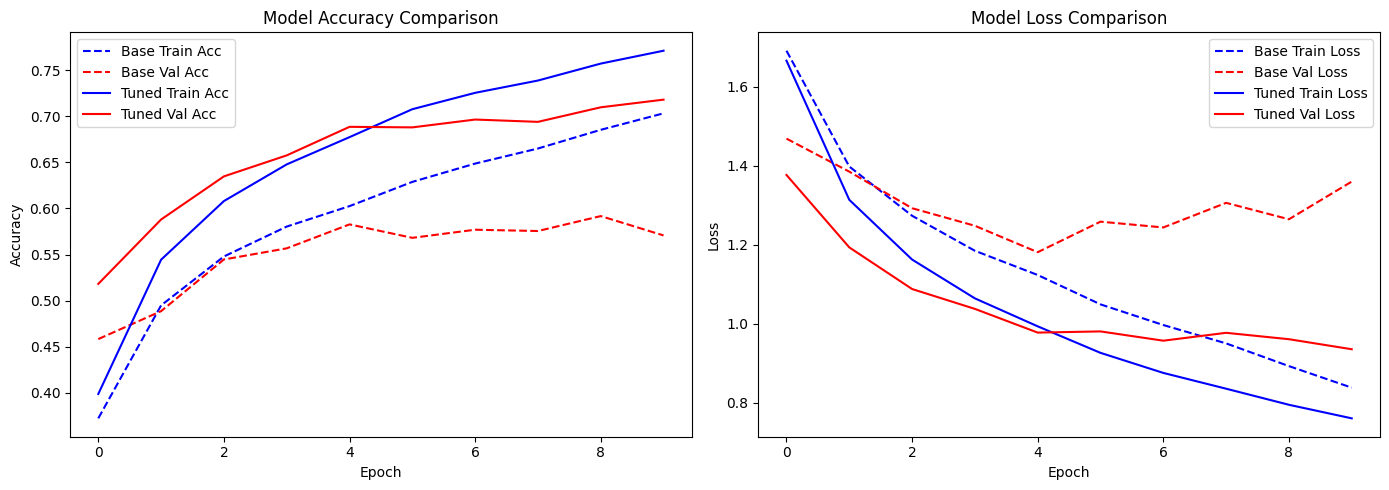

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history_base.history['accuracy'], 'b--', label='Base Train Acc')
ax1.plot(history_base.history['val_accuracy'], 'r--', label='Base Val Acc')
ax1.plot(history_tuned.history['accuracy'], 'b-', label='Tuned Train Acc')
ax1.plot(history_tuned.history['val_accuracy'], 'r-', label='Tuned Val Acc')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history_base.history['loss'], 'b--', label='Base Train Loss')
ax2.plot(history_base.history['val_loss'], 'r--', label='Base Val Loss')
ax2.plot(history_tuned.history['loss'], 'b-', label='Tuned Train Loss')
ax2.plot(history_tuned.history['val_loss'], 'r-', label='Tuned Val Loss')
ax2.set_title('Model Loss Comparison')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

### Step 8: Display Predictions on Sample Images

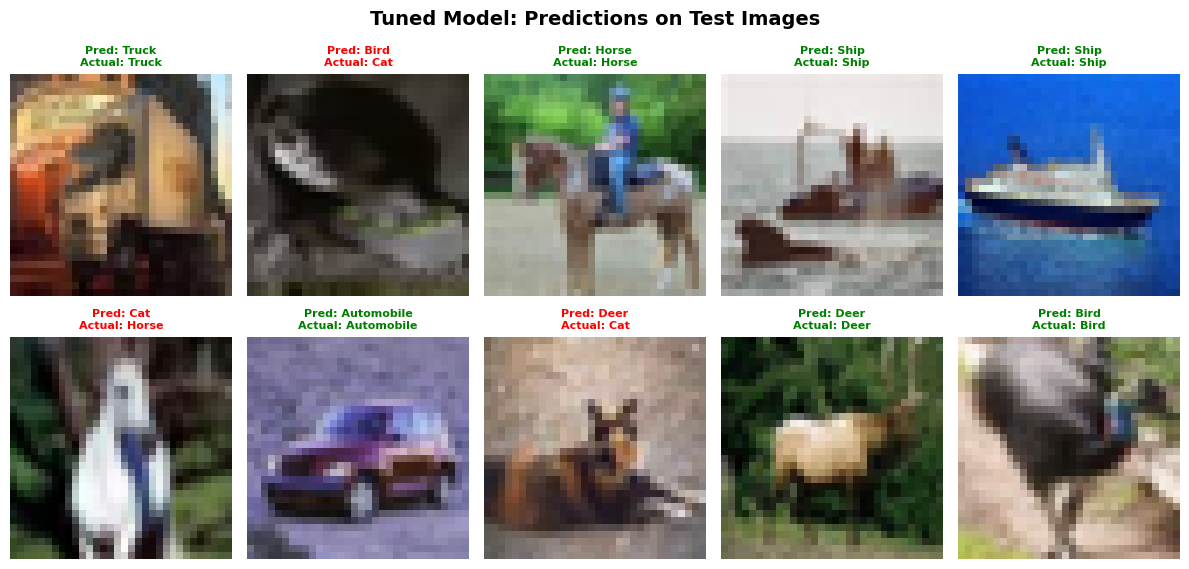

In [9]:
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

y_pred_tuned = np.argmax(model_tuned.predict(x_test, verbose=0), axis=1)
y_true = y_test.flatten()

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    idx = np.random.randint(0, len(x_test))
    ax = axes[i//5, i%5]
    ax.imshow(x_test[idx])
    predicted_class = class_names[y_pred_tuned[idx]]
    actual_class = class_names[y_true[idx]]
    color = 'green' if y_pred_tuned[idx] == y_true[idx] else 'red'
    ax.set_title(f'Pred: {predicted_class}\nActual: {actual_class}', color=color, fontweight='bold', fontsize=8)
    ax.axis('off')
plt.suptitle('Tuned Model: Predictions on Test Images', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()